# OLS

In [1]:
import pandas as pd

df = pd.read_csv('../data/ds_salaries.csv')
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [2]:
# 不要列削除
df = df.drop(columns=["salary", 'salary_currency'])

In [3]:
# 列の並び替え
df = df[['work_year', 'experience_level', 'employment_type', 
         'job_title', 'employee_residence', 'company_location', 
         'company_size','remote_ratio','salary_in_usd']]

In [4]:
# train_test分割
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=123)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

## バリデーション設計

### ホールドアウト検証

In [5]:
# OLS用
train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)
print(train_tr.shape, train_va.shape)
print('train_df : {}, train_tr : {}, train_va : {}'.format(
    train_df['salary_in_usd'].mean(), train_tr['salary_in_usd'].mean(), train_va['salary_in_usd'].mean())
)

(2403, 9) (601, 9)
train_df : 138580.20539280958, train_tr : 138685.56346233873, train_va : 138158.94841930116


### クロスバリデーション

In [6]:
# OLS用
from sklearn.model_selection import KFold

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))

for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    print(train_fold.shape, valid_fold.shape)
    print('train_df : {}, train_fold : {}, valid_fold : {}'.format(
        train_df['salary_in_usd'].mean(), train_fold['salary_in_usd'].mean(), valid_fold['salary_in_usd'].mean()
    ))

-------------------- 0 --------------------
(2403, 9) (601, 9)
train_df : 138580.20539280958, train_fold : 138685.56346233873, valid_fold : 138158.94841930116
-------------------- 1 --------------------
(2403, 9) (601, 9)
train_df : 138580.20539280958, train_fold : 138513.01872659175, valid_fold : 138848.84026622295
-------------------- 2 --------------------
(2403, 9) (601, 9)
train_df : 138580.20539280958, train_fold : 137816.09696213066, valid_fold : 141635.3677204659
-------------------- 3 --------------------
(2403, 9) (601, 9)
train_df : 138580.20539280958, train_fold : 139056.01872659175, valid_fold : 136677.74376039935
-------------------- 4 --------------------
(2404, 9) (600, 9)
train_df : 138580.20539280958, train_fold : 138830.22504159732, valid_fold : 137578.46


## モデル学習（ベースラインOLS）

### ホールドアウト検証の場合

In [7]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='salary_in_usd ~ work_year + remote_ratio + C(experience_level)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred = model_ols.predict(train_va)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.19197574210703894
RMSE : 56969.01838402311


### クロスバリデーションの場合

In [8]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='salary_in_usd ~ work_year + remote_ratio + C(experience_level)', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred = model_ols.predict(valid_fold)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.19197574210702395
RMSE : 56969.01838402364
-------------------- 1 --------------------
R2 : 0.20529132742333323
RMSE : 56499.003087171135
-------------------- 2 --------------------
R2 : 0.1545848335313854
RMSE : 61611.74745018092
-------------------- 3 --------------------
R2 : 0.19832172341345755
RMSE : 53330.6630391187
-------------------- 4 --------------------
R2 : 0.28476667010172174
RMSE : 54896.61398712946
------------------ total ------------------
   fold        R2          RMSE
0     0  0.191976  56969.018384
1     1  0.205291  56499.003087
2     2  0.154585  61611.747450
3     3  0.198322  53330.663039
4     4  0.284767  54896.613987
CV Results
R2   : 0.207 ± 0.048
RMSE : 56661 ± 3116


In [9]:
# 評価
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

model_final = smf.ols(
    formula='salary_in_usd ~ work_year + remote_ratio + C(experience_level)', 
    data=train_df
).fit()

pred = model_final.predict(test_df)
y_test = test_df['salary_in_usd']

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print('R2 :', r2)
print('RMSE :', rmse)

R2 : 0.24482186928714067
RMSE : 52252.60394235495


## モデル学習（会社属性追加）

### ホールドアウト検証の場合

In [10]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='salary_in_usd ~ work_year + remote_ratio + C(experience_level) + C(employment_type) + C(company_size)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred = model_ols.predict(train_va)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.2063713700959282
RMSE : 56459.26239236956


### クロスバリデーションの場合

In [11]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='salary_in_usd ~ work_year + remote_ratio + C(experience_level) + C(employment_type) + C(company_size)', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred = model_ols.predict(valid_fold)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.2063713700959534
RMSE : 56459.26239236867
-------------------- 1 --------------------
R2 : 0.21184355548496114
RMSE : 56265.6090307036
-------------------- 2 --------------------
R2 : 0.1697890765485668
RMSE : 61055.21021422029
-------------------- 3 --------------------
R2 : 0.20133407823766247
RMSE : 53230.37213512258
-------------------- 4 --------------------
R2 : 0.2722778629906146
RMSE : 55373.81927652357
------------------ total ------------------
   fold        R2          RMSE
0     0  0.206371  56459.262392
1     1  0.211844  56265.609031
2     2  0.169789  61055.210214
3     3  0.201334  53230.372135
4     4  0.272278  55373.819277
CV Results
R2   : 0.212 ± 0.037
RMSE : 56477 ± 2862


## モデル学習（job_title追加）

In [12]:
import numpy as np

counts = train_df['job_title'].value_counts()
major_jobs = counts[counts >= 30].index

train_df['job_title_mod'] = np.where(
    train_df['job_title'].isin(major_jobs), 
    train_df['job_title'], 
    'Other', 
)

test_df['job_title_mod'] = np.where(
    test_df['job_title'].isin(major_jobs), 
    test_df['job_title'], 
    'Other', 
)

### ホールドアウト検証の場合

In [13]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='salary_in_usd ~ work_year + remote_ratio + C(experience_level) + C(employment_type) + C(company_size) + C(job_title_mod)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred = model_ols.predict(train_va)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.26961460057022046
RMSE : 54162.98342387799


### クロスバリデーションの場合

In [14]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='salary_in_usd ~ work_year + remote_ratio + C(experience_level) + C(employment_type) + C(company_size) + C(job_title_mod)', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred = model_ols.predict(valid_fold)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.2696146005702369
RMSE : 54162.983423877384
-------------------- 1 --------------------
R2 : 0.2417388817354269
RMSE : 55188.196523888495
-------------------- 2 --------------------
R2 : 0.22122392704071236
RMSE : 59133.666702111776
-------------------- 3 --------------------
R2 : 0.2609302600434843
RMSE : 51205.85663479467
-------------------- 4 --------------------
R2 : 0.3178111379776847
RMSE : 53613.480041089635
------------------ total ------------------
   fold        R2          RMSE
0     0  0.269615  54162.983424
1     1  0.241739  55188.196524
2     2  0.221224  59133.666702
3     3  0.260930  51205.856635
4     4  0.317811  53613.480041
CV Results
R2   : 0.262 ± 0.036
RMSE : 54661 ± 2897


## モデル学習（interaction）

### ホールドアウト検証の場合

In [15]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='salary_in_usd ~ work_year + remote_ratio + C(employment_type) + C(company_size) + C(job_title_mod) * C(experience_level)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred = model_ols.predict(train_va)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.2835060950438021
RMSE : 53645.43694120159


### クロスバリデーションの場合

In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='salary_in_usd ~ work_year + remote_ratio + C(employment_type) + C(company_size) + C(job_title_mod) * C(experience_level)', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred = model_ols.predict(valid_fold)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.28350609504378543
RMSE : 53645.43694120222
-------------------- 1 --------------------
R2 : -0.21090286893510224
RMSE : 69741.52870564912
-------------------- 2 --------------------
R2 : 0.21329787530303002
RMSE : 59433.823576354596
-------------------- 3 --------------------
R2 : 0.2701446210797446
RMSE : 50885.6506390039
-------------------- 4 --------------------
R2 : 0.31224411976530897
RMSE : 53831.792590688034
------------------ total ------------------
   fold        R2          RMSE
0     0  0.283506  53645.436941
1     1 -0.210903  69741.528706
2     2  0.213298  59433.823576
3     3  0.270145  50885.650639
4     4  0.312244  53831.792591
CV Results
R2   : 0.174 ± 0.218
RMSE : 57508 ± 7511


## モデル学習（国追加）

In [17]:
counts = train_df['employee_residence'].value_counts()
major_countries = counts[counts >= 30].index

train_df['employee_residence_mod'] = np.where(
    train_df['employee_residence'].isin(major_countries),
    train_df['employee_residence'],
    'Other'
)

test_df['employee_residence_mod'] = np.where(
    test_df['employee_residence'].isin(major_countries),
    test_df['employee_residence'],
    'Other'
)

### ホールドアウト検証の場合

In [18]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='salary_in_usd ~ work_year + remote_ratio + C(employment_type) +C(company_size) + \
    C(job_title_mod) * C(experience_level) + C(employee_residence_mod)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred = model_ols.predict(train_va)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.3660303377044667
RMSE : 50461.571885449484


### クロスバリデーションの場合

In [19]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='salary_in_usd ~ work_year + remote_ratio + C(employment_type) +C(company_size) + \
        C(job_title_mod) * C(experience_level) + C(employee_residence_mod)', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred = model_ols.predict(valid_fold)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.3660303377044707
RMSE : 50461.57188544933
-------------------- 1 --------------------
R2 : 0.30967664600191525
RMSE : 52657.84619220067
-------------------- 2 --------------------
R2 : 0.36133976406616486
RMSE : 53550.489837465095
-------------------- 3 --------------------
R2 : 0.41234364421055325
RMSE : 45660.28776202386
-------------------- 4 --------------------
R2 : 0.4040879451059838
RMSE : 50108.65796095386
------------------ total ------------------
   fold        R2          RMSE
0     0  0.366030  50461.571885
1     1  0.309677  52657.846192
2     2  0.361340  53550.489837
3     3  0.412344  45660.287762
4     4  0.404088  50108.657961
CV Results
R2   : 0.371 ± 0.041
RMSE : 50488 ± 3063


## モデル学習（same_country追加）

In [20]:
train_df['same_country'] = train_df['employee_residence'] == train_df['company_location']
test_df['same_country'] = test_df['employee_residence'] == test_df['company_location']

### ホールドアウト検証の場合

In [21]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='salary_in_usd ~ work_year + remote_ratio + C(employment_type) +C(company_size) + \
    C(job_title_mod) * C(experience_level) + C(employee_residence_mod) + same_country', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred = model_ols.predict(train_va)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.36633098242431306
RMSE : 50449.60537893372


### クロスバリデーションの場合

In [22]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='salary_in_usd ~ work_year + remote_ratio + C(employment_type) +C(company_size) + \
        C(job_title_mod) * C(experience_level) + C(employee_residence_mod) + same_country', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred = model_ols.predict(valid_fold)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.36633098242424555
RMSE : 50449.6053789364
-------------------- 1 --------------------
R2 : 0.30942840323772247
RMSE : 52667.313316739135
-------------------- 2 --------------------
R2 : 0.36115821047299623
RMSE : 53558.10076456879
-------------------- 3 --------------------
R2 : 0.4098818723763533
RMSE : 45755.82636636756
-------------------- 4 --------------------
R2 : 0.404290254433309
RMSE : 50100.15141258648
------------------ total ------------------
   fold        R2          RMSE
0     0  0.366331  50449.605379
1     1  0.309428  52667.313317
2     2  0.361158  53558.100765
3     3  0.409882  45755.826366
4     4  0.404290  50100.151413
CV Results
R2   : 0.370 ± 0.040
RMSE : 50506 ± 3030


## モデル学習（給与の対数変換）

### ホールドアウト検証の場合

In [23]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='np.log(salary_in_usd) ~ work_year + remote_ratio + C(employment_type) +C(company_size) + \
    C(job_title_mod) * C(experience_level) + C(employee_residence_mod)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred_log = model_ols.predict(train_va)
y_pred = np.exp(y_pred_log)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.3430401094448231
RMSE : 51368.39121821648


### クロスバリデーションの場合

In [24]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    model_ols = smf.ols(
        formula='np.log(salary_in_usd) ~ work_year + remote_ratio + C(employment_type) +C(company_size) + \
        C(job_title_mod) * C(experience_level) + C(employee_residence_mod)', 
        data=train_fold
    ).fit()
    y_true = valid_fold['salary_in_usd']
    y_pred_log = model_ols.predict(valid_fold)
    y_pred = np.exp(y_pred_log)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    r2 = r2_score(y_true, y_pred)
    print('RMSE :', rmse)
    print('R2 :', r2)
    scores.append({'fold': nfold, 'RMSE': rmse, 'R2': r2})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('\nCV mean')
print(score_df[['RMSE','R2']].mean())

-------------------- 0 --------------------
RMSE : 51368.39121820644
R2 : 0.34304010944508
-------------------- 1 --------------------
RMSE : 104640.06623992142
R2 : -1.7259783013358612
-------------------- 2 --------------------
RMSE : 54210.25404819277
R2 : 0.34550570299808947
-------------------- 3 --------------------
RMSE : 45249.41904644138
R2 : 0.4228719740111595
-------------------- 4 --------------------
RMSE : 51576.70898067112
R2 : 0.3686591618500352
------------------ total ------------------
   fold           RMSE        R2
0     0   51368.391218  0.343040
1     1  104640.066240 -1.725978
2     2   54210.254048  0.345506
3     3   45249.419046  0.422872
4     4   51576.708981  0.368659

CV mean
RMSE    61408.967907
R2         -0.049180
dtype: float64


# 考察

In [25]:
train_df['job_title_mod'].value_counts()

job_title_mod
Data Engineer                827
Data Scientist               673
Data Analyst                 489
Other                        462
Machine Learning Engineer    226
Analytics Engineer            89
Data Architect                75
Research Scientist            60
Data Science Manager          53
Applied Scientist             50
Name: count, dtype: int64

In [26]:
train_df.groupby('job_title_mod')['salary_in_usd'].mean()

job_title_mod
Analytics Engineer           154137.483146
Applied Scientist            192276.800000
Data Analyst                 107998.554192
Data Architect               162782.893333
Data Engineer                143659.053204
Data Science Manager         188258.660377
Data Scientist               141858.265973
Machine Learning Engineer    157759.730088
Other                        125580.683983
Research Scientist           166941.950000
Name: salary_in_usd, dtype: float64

In [27]:
train_df['employee_residence_mod'].value_counts()

employee_residence_mod
US       2421
Other     241
GB        116
CA         71
ES         65
IN         55
DE         35
Name: count, dtype: int64

In [28]:
train_df.groupby('employee_residence_mod')['salary_in_usd'].mean().sort_values()

employee_residence_mod
IN        34515.527273
ES        57726.846154
Other     68257.896266
GB        90998.905172
DE        94584.342857
CA       132061.915493
US       153222.413879
Name: salary_in_usd, dtype: float64

<Axes: xlabel='work_year', ylabel='salary_in_usd'>

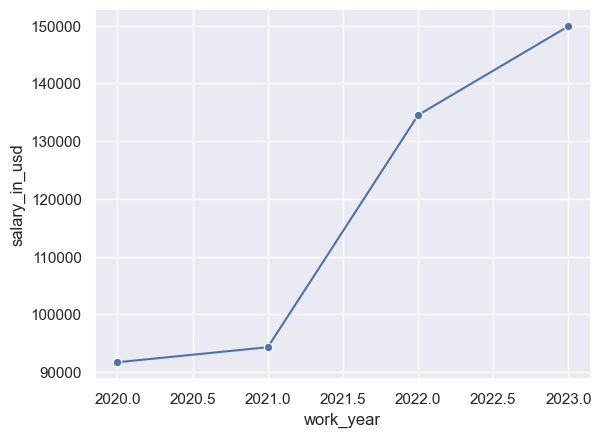

In [29]:
import seaborn as sns
sns.set()

mean_salary_df = pd.DataFrame(train_df.groupby('work_year')['salary_in_usd'].mean())
sns.lineplot(x='work_year', y='salary_in_usd', data=mean_salary_df, marker='o')

In [30]:
# 国コードを国名に変換
country_map = {
    'US': 'US',          # そのまま
    'GB': 'UK',          # 変更
    'CA': 'Canada',
    'IN': 'India',
    'DE': 'Germany',
    'ES': 'Spain',
    'Other': 'Other'     # そのまま
}

train_df['country_name'] = train_df['employee_residence_mod'].map(country_map).fillna('Other')

<Axes: xlabel='country_name', ylabel='salary_in_usd'>

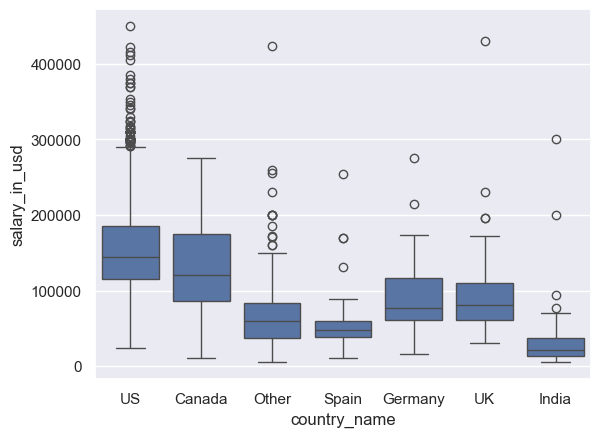

In [31]:
import seaborn as sns
sns.set()

sns.boxplot(x='country_name', y='salary_in_usd', data=train_df)

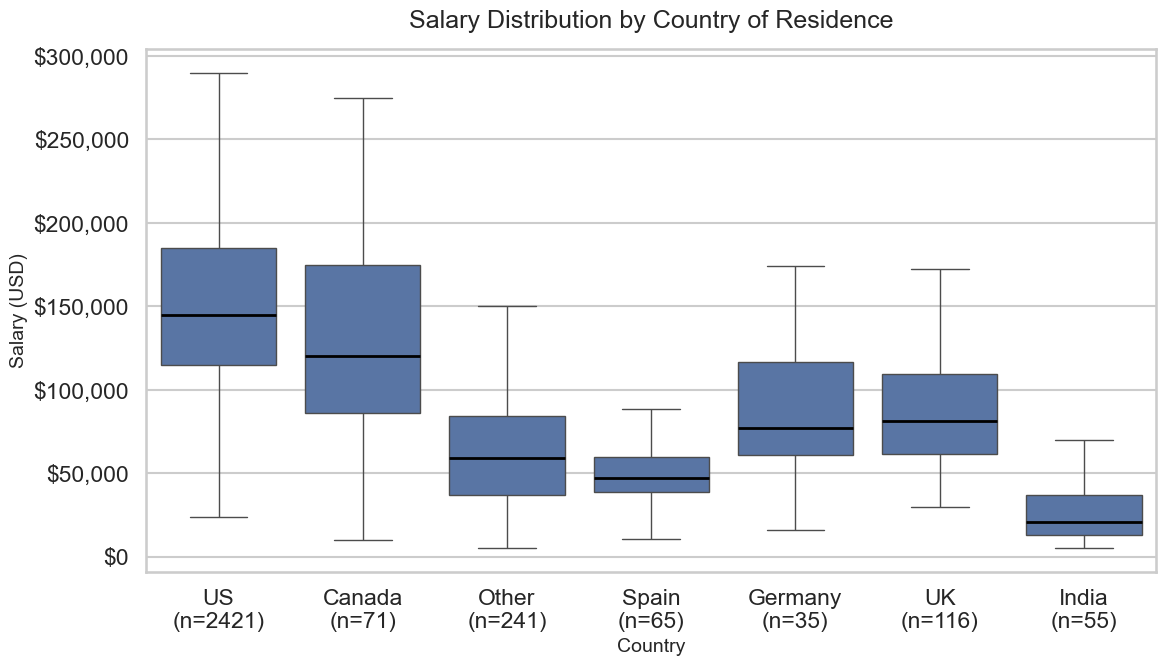

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# スタイル設定
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

# 箱ひげ図
sns.boxplot(
    x='country_name',
    y='salary_in_usd',
    data=train_df, 
    showfliers=False,    # 外れ値の非表示
    medianprops={"color": "black", "linewidth": 2}   # 中央値の強調
)

# タイトルとラベル
plt.title('Salary Distribution by Country of Residence', fontsize=18, pad=15)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Salary (USD)', fontsize=14)

# x軸にサンプル数の表示
counts = train_df['country_name'].value_counts()
labels = [
    f"{cat}\n(n={counts[cat]})"
    for cat in train_df['country_name'].unique()
]
plt.xticks(ticks=range(len(labels)), labels=labels)

# ドル＋カンマ
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
)

# レイアウト調整
plt.tight_layout()

# 保存（GitHub用）
plt.savefig('../images/boxplot.png', dpi=300)

# 表示
plt.show()

High-income countries such as the United States and Canada exhibit higher median salaries and wider interquartile ranges, indicating greater variability in compensation. In contrast, lower-income countries such as India and Spain show lower median salaries and more compact interquartile ranges.

This boxplot excludes outliers and therefore highlights differences in central tendency and dispersion across countries. It is worth noting that the United States also contains many high-income outliers, which are not shown in this figure.

In [33]:
# 米国企業に海外からリモート勤務する社員の平均給与
train_df.loc[(~train_df['same_country']) & (train_df['company_location'] == 'US'), 'salary_in_usd'].mean()

np.float64(74788.78125)

In [34]:
# 条件を固定した場合の国別の平均給与比較
df = train_df[
    (train_df['job_title'] == 'Data Scientist') &
    (train_df['experience_level'] == 'SE') &
    (train_df['employment_type'] == 'FT')
]

mean_salary_df = pd.DataFrame(
    df.groupby('employee_residence_mod')['salary_in_usd'].mean().sort_values()
)
mean_salary_df

,salary_in_usd
employee_residence_mod,
ES,45795.000000
IN,54094.000000
Other,92280.250000
GB,109858.666667
CA,163959.214286
US,166131.854586


In [35]:
# リモート率を0に固定した国別の平均給与比較
df = train_df.loc[train_df['remote_ratio'] == 0]

mean_salary_df = pd.DataFrame(
    df.groupby('employee_residence_mod')['salary_in_usd'].mean().sort_values()
)
mean_salary_df

,salary_in_usd
employee_residence_mod,
IN,26940.142857
ES,57606.250000
Other,75451.692308
GB,93928.742857
DE,118748.727273
CA,145075.590909
US,152738.713213


<Axes: xlabel='employee_residence_mod', ylabel='salary_in_usd'>

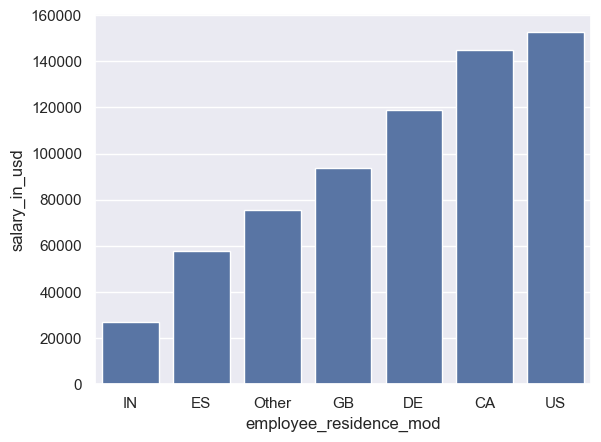

In [36]:
import seaborn as sns
sns.set()

sns.barplot(x='employee_residence_mod', y='salary_in_usd', data=mean_salary_df)

In [37]:
# リモート率を100に固定した国別の平均給与比較
df = train_df.loc[train_df['remote_ratio'] == 100]

mean_salary_df = pd.DataFrame(
    df.groupby('employee_residence_mod')['salary_in_usd'].mean().sort_values()
)
mean_salary_df

,salary_in_usd
employee_residence_mod,
IN,30607.758621
ES,61382.850000
Other,69570.192308
GB,88136.285714
DE,93112.400000
CA,129855.230769
US,153981.584514


<Axes: xlabel='employee_residence_mod', ylabel='salary_in_usd'>

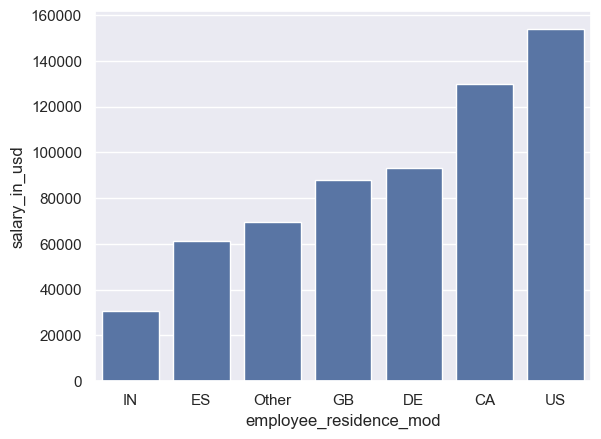

In [38]:
import seaborn as sns
sns.set()

sns.barplot(x='employee_residence_mod', y='salary_in_usd', data=mean_salary_df)

<Axes: xlabel='employee_residence_mod', ylabel='salary_in_usd'>

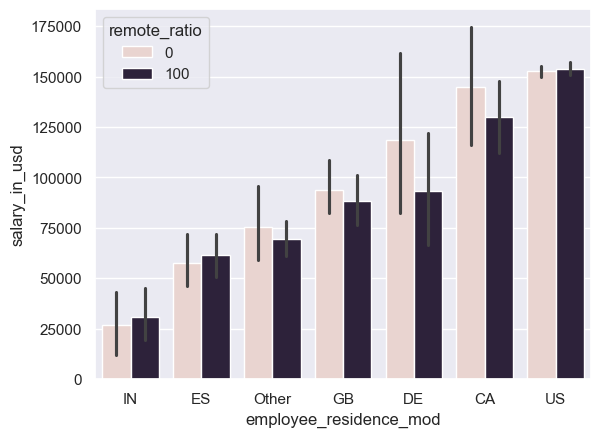

In [39]:
remote_df = train_df[train_df['remote_ratio'].isin([0, 100])]
order = remote_df.groupby('employee_residence_mod')['salary_in_usd'].mean().sort_values().index

import seaborn as sns
sns.set()

sns.barplot(
    x='employee_residence_mod',
    y='salary_in_usd',
    hue='remote_ratio',
    data=remote_df, 
    order=order
)

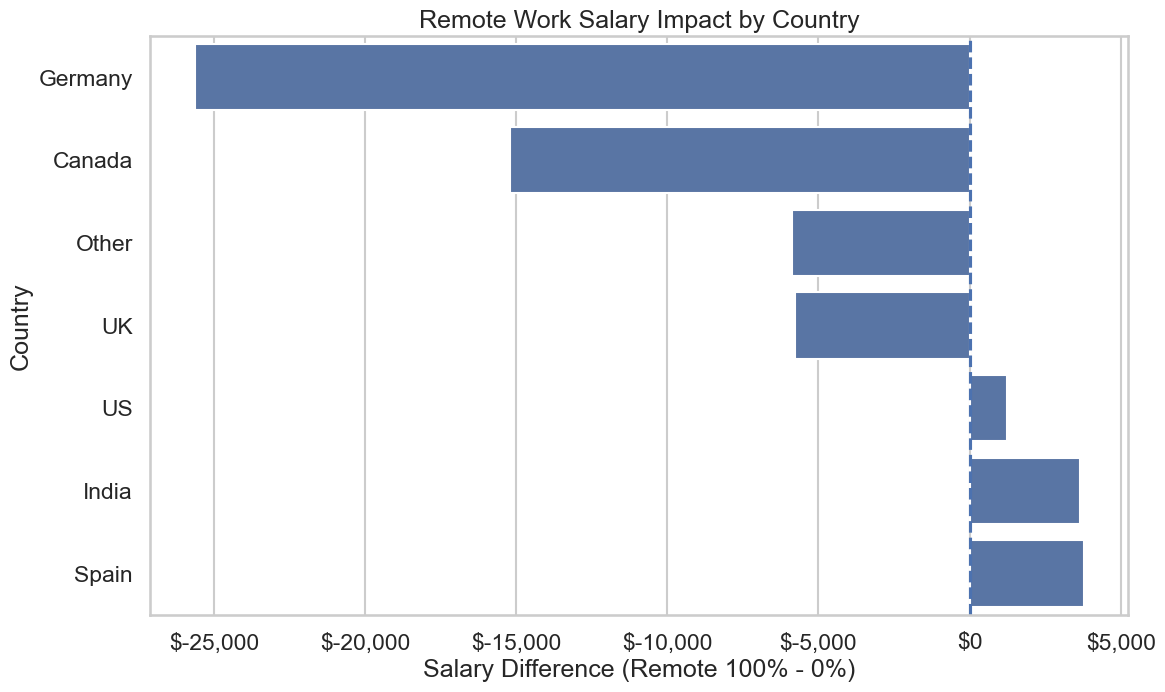

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

# 0と100に限定
df_remote = train_df[train_df['remote_ratio'].isin([0, 100])]

# 国×リモートで平均
pivot = df_remote.pivot_table(
    index='country_name',
    columns='remote_ratio',
    values='salary_in_usd',
    aggfunc='mean'
)

# 差分（100% - 0%）
pivot['diff_remote'] = pivot[100] - pivot[0]

# ソート
pivot = pivot.sort_values('diff_remote')

# プロット
sns.barplot(
    x=pivot['diff_remote'],
    y=pivot.index
)

# ドル表記
ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
)

plt.tight_layout()
plt.axvline(0, linestyle='--')  # 0ライン
plt.xlabel('Salary Difference (Remote 100% - 0%)')
plt.ylabel('Country')
plt.title('Remote Work Salary Impact by Country')
plt.savefig(
    '../images/remote_work_impact.png', 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

When the remote ratio increases from 0% to 100%, the impact on salary differs substantially across countries. 

In lower-income countries such as India and Spain, salaries increase by approximately $3,500. In the United States, the increase is modest at around $1,000. 

In contrast, several higher-income countries show a decrease in salaries: about $6,000 in the United Kingdom and other regions, approximately $15,000 in Canada, and up to $25,000 in Germany.

These results suggest that the relationship between remote work and salary varies by country, with potential differences between lower- and higher-income regions.

These patterns are based on descriptive comparisons and should be interpreted with caution, as they do not control for other factors such as job role, experience, or company characteristics.

## モデル学習（remote_ratio × employee_residence_mod）

### ホールドアウトの場合

In [55]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='salary_in_usd ~ remote_ratio * C(employee_residence_mod)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred = model_ols.predict(train_va)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.21569904430096243
RMSE : 56126.49329003522


### クロスバリデーションの場合

In [42]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='salary_in_usd ~ remote_ratio * C(employee_residence_mod)', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred = model_ols.predict(valid_fold)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.21569904430096276
RMSE : 56126.49329003521
-------------------- 1 --------------------
R2 : 0.29561725883755974
RMSE : 53191.368236681476
-------------------- 2 --------------------
R2 : 0.23301206236405958
RMSE : 58684.414529991234
-------------------- 3 --------------------
R2 : 0.2576471709381273
RMSE : 51319.46371173188
-------------------- 4 --------------------
R2 : 0.2224898497849941
RMSE : 57236.71754497491
------------------ total ------------------
   fold        R2          RMSE
0     0  0.215699  56126.493290
1     1  0.295617  53191.368237
2     2  0.233012  58684.414530
3     3  0.257647  51319.463712
4     4  0.222490  57236.717545
CV Results
R2   : 0.245 ± 0.033
RMSE : 55312 ± 3007


## モデル学習（最終形）　

### ホールドアウト検証の場合

In [60]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='salary_in_usd ~ work_year + C(employment_type) + C(company_size) + \
    C(job_title_mod) + C(experience_level) + remote_ratio * C(employee_residence_mod)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred = model_ols.predict(train_va)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.36196118661590193
RMSE : 50623.25732348944


### クロスバリデーションの場合

In [61]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='salary_in_usd ~ work_year + C(employment_type) +C(company_size) + \
        C(job_title_mod) + C(experience_level) + remote_ratio * C(employee_residence_mod)', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred = model_ols.predict(valid_fold)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.36196118661590937
RMSE : 50623.257323489146
-------------------- 1 --------------------
R2 : 0.4074162602009952
RMSE : 48787.849323188726
-------------------- 2 --------------------
R2 : 0.3728946166460023
RMSE : 53063.852085902916
-------------------- 3 --------------------
R2 : 0.40316820970477374
RMSE : 46015.367969765706
-------------------- 4 --------------------
R2 : 0.4042154962551321
RMSE : 50103.29495570858
------------------ total ------------------
   fold        R2          RMSE
0     0  0.361961  50623.257323
1     1  0.407416  48787.849323
2     2  0.372895  53063.852086
3     3  0.403168  46015.367970
4     4  0.404215  50103.294956
CV Results
R2   : 0.390 ± 0.021
RMSE : 49719 ± 2585


## モデル推論

In [62]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

model_final = smf.ols(
    formula='salary_in_usd ~ work_year + C(employment_type) +C(company_size) + \
        C(job_title_mod) + C(experience_level) + remote_ratio * C(employee_residence_mod)', 
    data=train_df
).fit()

pred = model_final.predict(test_df)
y_test = test_df['salary_in_usd']

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print('R2 :', r2)
print('RMSE :', rmse)

R2 : 0.4424752142274444
RMSE : 44896.79351669196


In [63]:
model_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          salary_in_usd   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     65.51
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:06:16   Log-Likelihood:                -36711.
No. Observations:                3004   AIC:                         7.349e+04
Df Residuals:                    2972   BIC:                         7.368e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
===================================================================================================================
                                                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                       -1.108e+07   3.07e+06     -3.613      0.000   -1.71e+07   -5.07e+06
C(employment_type)[T.FL]                         3167.6546   2.58e+04      0.123      0.902   -4.73e+04    5.37e+04
C(employment_type)[T.FT]                         1.514e+04   1.78e+04      0.853      0.394   -1.97e+04    4.99e+04
C(employment_type)[T.PT]                         7301.4844   2.23e+04      0.328      0.743   -3.63e+04    5.09e+04
C(company_size)[T.M]                            -5209.4152   3171.739     -1.642      0.101   -1.14e+04    1009.612
C(company_size)[T.S]                             -1.46e+04   5737.666     -2.545      0.011   -2.59e+04   -3351.962
C(job_title_mod)[T.Applied Scientist]            3.144e+04   8918.660      3.525      0.000     1.4e+04    4.89e+04
C(job_title_mod)[T.Data Analyst]                -3.169e+04   5750.643     -5.511      0.000    -4.3e+04   -2.04e+04
C(job_title_mod)[T.Data Architect]               4069.6654   7763.056      0.524      0.600   -1.12e+04    1.93e+04
C(job_title_mod)[T.Data Engineer]               -3763.1140   5532.025     -0.680      0.496   -1.46e+04    7083.873
C(job_title_mod)[T.Data Science Manager]          3.63e+04   8601.056      4.220      0.000    1.94e+04    5.32e+04
C(job_title_mod)[T.Data Scientist]               2030.2912   5617.163      0.361      0.718   -8983.632     1.3e+04
C(job_title_mod)[T.Machine Learning Engineer]    1.869e+04   6236.563      2.998      0.003    6466.174    3.09e+04
C(job_title_mod)[T.Other]                        3720.9735   5843.983      0.637      0.524   -7737.688    1.52e+04
C(job_title_mod)[T.Research Scientist]           3.584e+04   8343.114      4.296      0.000    1.95e+04    5.22e+04
C(experience_level)[T.EX]                        9.081e+04   6232.002     14.572      0.000    7.86e+04    1.03e+05
C(experience_level)[T.MI]                        1.813e+04   3788.220      4.787      0.000    1.07e+04    2.56e+04
C(experience_level)[T.SE]                        4.443e+04   3553.021     12.505      0.000    3.75e+04    5.14e+04
C(employee_residence_mod)[T.DE]                 -2.603e+04   1.71e+04     -1.523      0.128   -5.95e+04    7480.497
C(employee_residence_mod)[T.ES]                 -8.349e+04   1.27e+04     -6.594      0.000   -1.08e+05   -5.87e+04
C(employee_residence_mod)[T.GB]                 -3.064e+04   1.17e+04     -2.617      0.009   -5.36e+04   -7687.082
C(employee_residence_mod)[T.IN]                 -7.519e+04   1.81e+04     -4.153      0.000   -1.11e+05   -3.97e+04
C(employee_residence_mod)[T.Other]               -6.03e+04   1.18e+04     -5.096      0.000   -8.35e+04   -3.71e+04
C(employee_residence_mod)[T.US]                  1.172e+04   1.01e+

In [45]:
df_remote['employee_residence_mod'].value_counts()

employee_residence_mod
US       2391
Other     182
GB        105
CA         61
ES         60
IN         36
DE         26
Name: count, dtype: int64

In [46]:
df_remote['remote_label'] = df_remote['remote_ratio'].map({
    0: '0%',
    100: '100%'
})

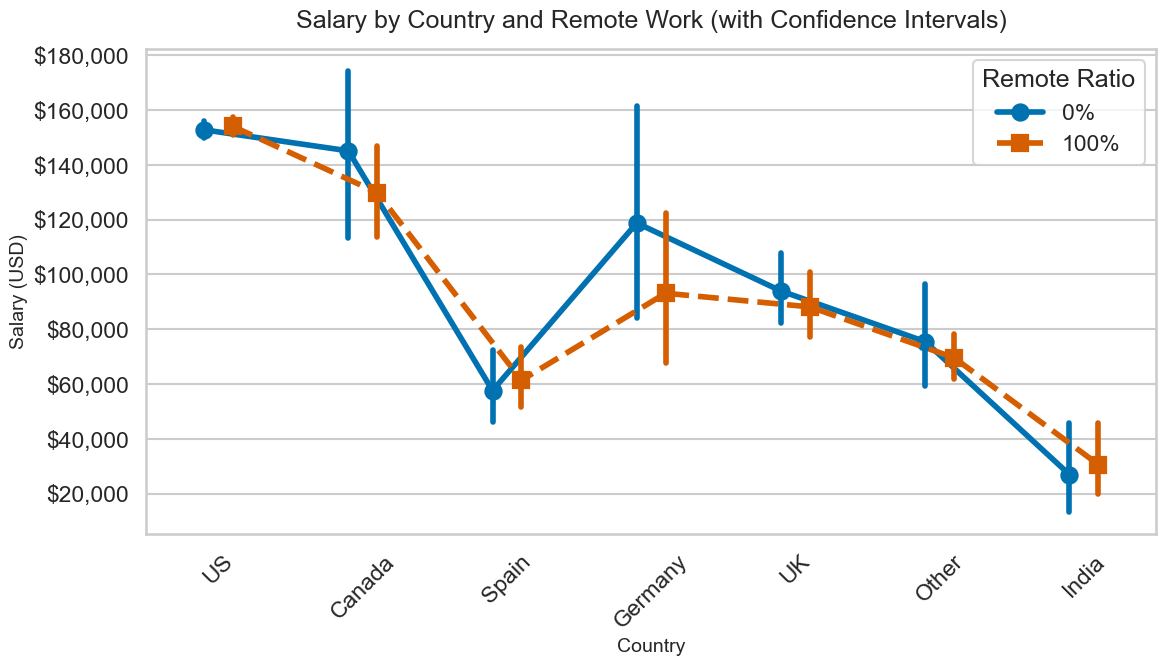

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

# pointplot
sns.pointplot(
    x='country_name',
    y='salary_in_usd',
    hue='remote_label',
    data=df_remote,
    dodge=0.2,          # 重なり防止
    markers=['o', 's'], # 0%と100%で形を変える
    linestyles=['-', '--'], 
    palette=['#0072B2', '#D55E00']
)

# x軸ラベル回転
plt.xticks(rotation=45)

# ドル表記（カンマ付き）
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
)

# タイトル・ラベル
plt.title('Salary by Country and Remote Work (with Confidence Intervals)', fontsize=18, pad=15)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Salary (USD)', fontsize=14)

# 凡例タイトル変更
plt.legend(title='Remote Ratio')

# レイアウト調整
plt.tight_layout()

# 保存
plt.savefig(
    '../images/pointplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Confidence intervals are much narrower for the United States due to a larger sample size, while other countries show higher uncertainty.

## モデル学習（対数変換 + 最終）

### ホールドアウト検証の場合

In [48]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

train_tr, train_va = train_test_split(train_df, test_size=0.2, shuffle=True,  random_state=123)

model_ols = smf.ols(
    formula='np.log(salary_in_usd) ~ work_year + C(employment_type) + C(company_size) + \
    C(job_title_mod) + C(experience_level) + remote_ratio * C(employee_residence_mod)', 
    data=train_tr).fit()

y_true = train_va['salary_in_usd']
y_pred_log = model_ols.predict(train_va)
y_pred = np.exp(y_pred_log)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

print('R2 :', r2_score(y_true, y_pred))
print('RMSE :', rmse)

R2 : 0.34411648591296773
RMSE : 51326.29245796151


### クロスバリデーションの場合

In [49]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

n_splits = 5
cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=123).split(train_df))
scores = []
for nfold, (idx_tr, idx_va) in enumerate(cv):
    print('-'*20, nfold, '-'*20)
    train_fold = train_df.iloc[idx_tr]
    valid_fold = train_df.iloc[idx_va]
    
    model_ols = smf.ols(
        formula='np.log(salary_in_usd) ~ work_year + C(employment_type) +C(company_size) + \
        C(job_title_mod) + C(experience_level) + remote_ratio * C(employee_residence_mod)', 
        data=train_fold
    ).fit()
    
    y_true = valid_fold['salary_in_usd']
    y_pred_log = model_ols.predict(valid_fold)
    y_pred = np.exp(y_pred_log)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    print('R2 :', r2)
    print('RMSE :', rmse)
    
    scores.append({'fold': nfold, 'R2': r2, 'RMSE': rmse})
print('-'*18, 'total', '-'*18)
score_df = pd.DataFrame(scores)
print(score_df)
print('CV Results')
print(f"R2   : {score_df['R2'].mean():.3f} ± {score_df['R2'].std():.3f}")
print(f"RMSE : {score_df['RMSE'].mean():.0f} ± {score_df['RMSE'].std():.0f}")

-------------------- 0 --------------------
R2 : 0.34411648591315036
RMSE : 51326.29245795436
-------------------- 1 --------------------
R2 : 0.39148884342177637
RMSE : 49439.15976582889
-------------------- 2 --------------------
R2 : 0.34789815273451385
RMSE : 54111.08278853404
-------------------- 3 --------------------
R2 : 0.4099158980432558
RMSE : 45754.50722798109
-------------------- 4 --------------------
R2 : 0.37169490407744943
RMSE : 51452.55871578488
------------------ total ------------------
   fold        R2          RMSE
0     0  0.344116  51326.292458
1     1  0.391489  49439.159766
2     2  0.347898  54111.082789
3     3  0.409916  45754.507228
4     4  0.371695  51452.558716
CV Results
R2   : 0.373 ± 0.028
RMSE : 50417 ± 3092


→ 給与を対数変換しても精度は上がらない